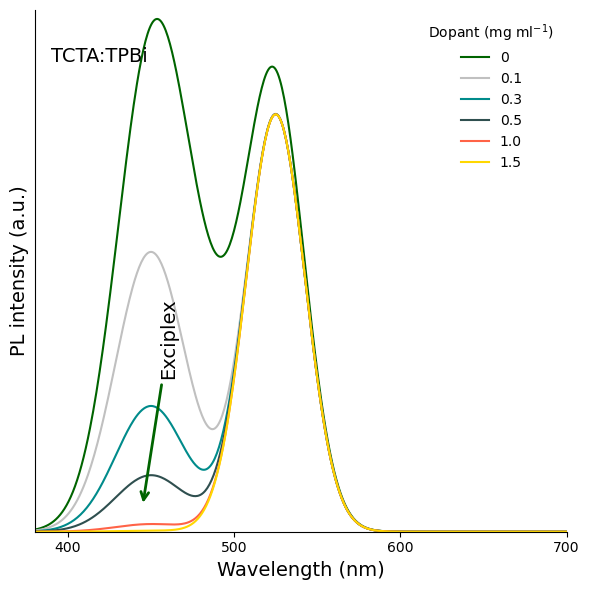

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data simulation
x = np.linspace(380, 700, 500)
def spectrum(x, center, width, height):
    return height * np.exp(-((x - center) / width)**2)

dopants = [0, 0.1, 0.3, 0.5, 1.0, 1.5]
colors = ['#006400', '#C0C0C0', '#008B8B', '#2F4F4F', '#FF6347', '#FFD700']

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

for d, color in zip(dopants, colors):
    # Exciplex intensity decreases with dopant
    h1 = 0.8 * np.exp(-4 * d) if d > 0 else 0.8
    y = spectrum(x, 450, 30, h1) + spectrum(x, 525, 25, 0.8)
    if d == 0:
        # Extra shoulder for d=0
        y += spectrum(x, 480, 40, 0.3)

    ax.plot(x, y, color=color, label=f'{d}')

# Annotations
ax.annotate('Exciplex', xy=(445, 0.05), xytext=(455, 0.3),
            arrowprops=dict(arrowstyle='->', color='#006400', lw=2),
            rotation=90, fontsize=14)
ax.text(390, 0.9, 'TCTA:TPBi', fontsize=14)

# Formatting
ax.set_xlabel('Wavelength (nm)', fontsize=14)
ax.set_ylabel('PL intensity (a.u.)', fontsize=14)
ax.set_xlim(380, 700)
ax.set_ylim(0, 1)
ax.set_xticks([400, 500, 600, 700])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Dopant (mg ml$^{-1}$)', frameon=False, loc='upper right')
plt.tight_layout()
plt.show()
